# MIS 583 Assignment 5: Text Sentiment Classification

**Your Answer:**   
Hi I'm 李圯瀞, B094020012

## Overview

**Sentiment Classification** is an automated process of identifying opinions in text and labeling them as positive, negative, or neutral, based on the emotions customers express within them.

In this assignment, you need to train a recurrent neural network (RNN)
or fine-tune a pre-trained language model (e.g., BERT) to predict the
sentiment of given tweet.

##  Versions of used packages

We will check PyTorch version to make sure everything work properly.  
We use `python==3.7.14`, `torch==1.12.1+cu113` and `torchvision==0.13.1+cu113`.  
This is the default version in Google Colab.

In [ ]:
import sys
import torch
import torchvision
print('python', sys.version.split('\n')[0])
print('torch', torch.__version__)
print('torchvision', torchvision.__version__)

python 3.8.15 (default, Oct 12 2022, 19:14:39) 
torch 1.12.1+cu113
torchvision 0.13.1+cu113


## Loading Model and Data

First, we are going to talk about the model.  
HuggingFace team have created an amazing framework called "transformers" for NLP tasks.  
It havs many State-of-the-art Machine Learning for Pytorch, TensorFlow, and JAX.  

To start with this package, follow [this link to installation and basic tutorial](https://pytorch.org/hub/huggingface_pytorch-transformers/).

In [ ]:
# you might need some additional installations there
!echo happy installation
!pip -V
!pip install transformers
!pip install tqdm boto3 requests regex sentencepiece sacremoses

happy installation
pip 21.1.3 from /usr/local/lib/python3.8/dist-packages/pip (python 3.8)
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
# from torch import nn
# from transformers import BertModel, BertTokenizer, BertForSequenceClassification


# #########################################################################
# #            Loading tokenizer and model from transformer               #
# #########################################################################
# # from transformers import xxx

# bert_type = 'bert-base-cased'


# # ---------- 1. load from torch.hub ----------
# tokenizer = torch.hub.load('huggingface/pytorch-transformers', 'tokenizer', bert_type)

# # create a Bert-extended task (classification)
# model = torch.hub.load('huggingface/pytorch-transformers', 'model', bert_type)

# # ---------- 2. load from installed huggingface ----------
# tokenizer = BertTokenizer.from_pretrained(bert_type)

# # create a Bert-extended task (classification)
# model = BertForSequenceClassification.from_pretrained(bert_type)

# # finetune from the output from bert to your task
# model.classifier = nn.Linear(768, 3, bias=True)
# #########################################################################
# #                          End of your code                             #
# #########################################################################

In [ ]:
from torch import nn
from transformers import RobertaModel, RobertaTokenizer, RobertaForSequenceClassification



tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
class BertClassifier(nn.Module):
    def __init__(self, dropout=0.5):
        super(BertClassifier, self).__init__()
        self.bert = RobertaModel.from_pretrained('roberta-base')
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(768, 3)
        self.relu = nn.ReLU()

    def forward(self, input_id, mask):
        _, pooled_output = self.bert(input_ids= input_id, attention_mask=mask,return_dict=False)
        dropout_output = self.dropout(pooled_output)
        linear_output = self.linear(dropout_output)
        # final_layer = self.relu(linear_output)
        final_layer = linear_output
        return final_layer

model = BertClassifier()

Some weights of the model checkpoint at roberta-base were not used when initializing RobertaModel: ['lm_head.dense.weight', 'lm_head.decoder.weight', 'lm_head.dense.bias', 'lm_head.layer_norm.bias', 'lm_head.bias', 'lm_head.layer_norm.weight']
- This IS expected if you are initializing RobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).






## How to Get Data

Please open the file `twitter_sentiment.zip`, creat shortcut to your Google Drive.

1. open [LINK of Google Drive](https://drive.google.com/file/d/14SdYQ6FSowQnWVCd4dP12jQMjX9-YJIh/view?usp=sharing)
2. Click "Add shortcut to Drive" in the top-right corner.
3. Select the location where you want to place the shortcut.
4. Click Add shortcut.

After above procedures, we have a shortcut of zip file of dataset.  
We can access this in colab after granting the permission of Google Drive.

---

請先到共用雲端硬碟將檔案 `twitter_sentiment.zip`，建立捷徑到自己的雲端硬碟中。

> 操作步驟
1. 點開雲端[連結](https://drive.google.com/file/d/14SdYQ6FSowQnWVCd4dP12jQMjX9-YJIh/view?usp=sharing)
2. 點選右上角「新增雲端硬碟捷徑」
3. 點選「我的雲端硬碟」
4. 點選「新增捷徑」

完成以上流程會在你的雲端硬碟中建立一個檔案的捷徑，接著我們在colab中取得權限即可使用。

1. Executing the below code which will provide you with an authentication link
2. Open the link
3. Choose the Google account whose Drive you want to mount
4. Allow Google Drive Stream access to your Google Account
5. Copy the code displayed, paste it in the text box as shown below, and press Enter
![](https://i1.wp.com/neptune.ai/wp-content/uploads/colab-code-copy.png?resize=512%2C102&ssl=1)

Might be some outdated. Don't need the code right now, I think.  

Finish!

---

執行此段後點選出現的連結，允許授權後，複製授權碼，貼在空格中後按下ENTER，即完成與雲端硬碟連結。

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Unzip Data

Unzip `twitter_sentiment.zip`, there are 3 csv files.

- `train.csv`, `test.csv` and `val.csv`

There are **10248** datas in training set.  
There are **1461** datas in validation set.  
There are **2928** datas in testing set.  

---

解壓縮 `twitter_sentiment.zip` 後可以發現裡面有兩個資料夾和三個csv檔。

- `train.csv`, `test.csv` and `val.csv`

Training set 有 **10248** 筆資料.  
Validation set 有 **1461** 筆資料.  
Testing set 有 **2928** 筆資料.  

注意: 若有另外設定存放在雲端硬碟中的路徑，請記得本處路徑也須做更動。

In [ ]:
!unzip -qq ./drive/MyDrive/Deep\ Learning/assignment5/twitter_sentiment.zip

replace twitter_sentiment/val.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [ ]:
# Utility function to extract text and label from csv file
def get_texts(f_name='./twitter_sentiment', mode='train'):
    text_list = []
    label_list = []

    f_path = os.path.join(f_name, '{}.csv'.format(mode))
    with open(f_path) as f:
        reader = csv.DictReader(f)
        for line in reader:
            text_list.append(line['text'])
            if mode != 'test':
                label_list.append(int(line['sentiment_label']))

    return text_list, label_list

In [ ]:
import os
import csv
import torch
from torch.utils.data import Dataset, DataLoader
class TwitterDataset(Dataset):
    def __init__(self, f_name='./twitter_sentiment', mode='train'):
        self.mode = mode

        text_list, label_list = get_texts(f_name, mode)
        print('mode', mode, 'has', len(text_list), 'datas')
        text_list = tokenizer(text_list,
                             truncation=True, padding=True,
                             return_tensors='pt')

        self.text_list = text_list['input_ids']
        self.mask_list = text_list['attention_mask']

        self.label_list = label_list

    def __getitem__(self, idx):
        text = self.text_list[idx]
        mask = self.mask_list[idx]
        if self.mode == 'test':
            return text, mask
        label = torch.tensor(self.label_list[idx])
        return text, mask, label

    def __len__(self):
        return len(self.text_list)

In [ ]:
dataset_train = TwitterDataset(mode='train')
dataset_val = TwitterDataset(mode='val')
dataset_test = TwitterDataset(mode='test')

batch_size = 64
train_data = DataLoader(dataset_train, batch_size=batch_size,
                       shuffle=True)
val_data = DataLoader(dataset_val, batch_size=batch_size // 2,
                       shuffle=False)
test_data = DataLoader(dataset_test, batch_size=batch_size // 2,
                       shuffle=False)

mode train has 10248 datas
mode val has 1464 datas
mode test has 2928 datas


In [ ]:
t = tokenizer.convert_ids_to_tokens(dataset_train[0][0])
print('token', t)
print('token to s', tokenizer.convert_tokens_to_string(t))

token ['<s>', '@', 'united', 'Ġsat', 'Ġat', 'Ġairport', 'Ġfor', 'Ġ5', 'Ġhrs', 'Ġstill', 'Ġsitting', 'Ġat', 'Ġgate', '..', 'Ġ', 'ĠS', 'igh', '</s>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>

In [ ]:
device = torch.device('cuda')

from torch import nn
from transformers import AdamW
from torch.optim import Adam

optimizer = Adam(model.parameters(),lr=2e-6)
criterion = nn.CrossEntropyLoss()

model = model.to(device)
criterion = criterion.to(device)

## Utility Function

In [ ]:
def accuracy(raw_preds, y):
    preds = raw_preds.argmax(dim=1)
    acc = (preds == y).sum()
    return acc

In [ ]:
from tqdm import tqdm
import matplotlib.pyplot as plt

train_loss_list = []
val_loss_list = []

def train(model, data, optimizer, criterion):
    model.train()

    epoch_loss = 0
    epoch_acc = 0
    total = 0
    for text, mask, label in tqdm(data, total=len(data)):
        text = text.to(device)
        mask = mask.to(device)
        label = label.to(device)

        #########################################################################
        #                          Testing process                              #
        #########################################################################
        # 1. clean the gradients of optimizer
        # 2. put correct variables into model
        # 3. get prediction
        # 4. Evalutate by criterion and accuracy
        #########################################################################
        #                          End of your code                             #
        #########################################################################
        optimizer.zero_grad()
        output = model(text, mask)
        loss = criterion(output, label)
        acc = accuracy(output, label)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        train_loss_list.append(loss.item())
        epoch_acc += acc.item()
        total += len(text)

    return epoch_loss / total, epoch_acc / total

def test(model, data, criterion, log_loss=False):
    model.eval()

    epoch_loss = 0
    epoch_acc = 0
    total = 0
    for text, mask, label in tqdm(data, total=len(data)):
        text = text.to(device)
        mask = mask.to(device)
        label = label.to(device)

        #########################################################################
        #                          Training process                             #
        #########################################################################
        # 1. put correct variables into model
        # 2. get prediction
        # 3. Evalutate by criterion and accuracy
        #########################################################################
        #                          End of your code                             #
        #########################################################################
        output = model(text, mask)
        loss = criterion(output, label)
        acc = accuracy(output, label)

        optimizer.zero_grad()


        epoch_loss += loss.item()
        if log_loss:
            val_loss_list.append(loss.item())
        epoch_acc += acc.item()
        total += len(text)
    return epoch_loss / total, epoch_acc / total

# class for monitoring train and test acc/loss
class Meter:
    def __init__(self):
        self.train_loss_list = []
        self.train_acc_list = []
        self.val_loss_list = []
        self.val_acc_list = []

    def update(self, train_loss, train_acc, val_loss, val_acc):
        self.train_loss_list.append(train_loss)
        self.train_acc_list.append(train_acc)
        self.val_loss_list.append(val_loss)
        self.val_acc_list.append(val_acc)

    def plot(self):
        x = range(len(self.train_loss_list))
        plt.plot(x, self.train_loss_list)
        plt.plot(x, self.val_loss_list, color='r')
        plt.legend(['train_loss', 'val_loss'])
        plt.show()
        plt.plot(x, self.train_acc_list)
        plt.plot(x, self.val_acc_list, color='r')
        plt.legend(['train_acc', 'val_acc'])
        plt.show()

In [ ]:
import torch
torch.cuda.empty_cache()

## Start Training

In [ ]:
#########################################################################
#                          Hyper-parameters                             #
#########################################################################
max_epoch = 2
log_interval = 1
best_acc = 0
#########################################################################
#                          End of your code                             #
#########################################################################

m = Meter()

for epoch in range(1, max_epoch + 1):
    train_loss, train_acc = train(model, train_data, optimizer, criterion)
    val_loss, val_acc = test(model, val_data, criterion, log_loss=True)

    if epoch % log_interval == 0:
        print('Epoch {} train_loss: {} train_acc: {}'.format(
            epoch, train_loss, train_acc
        ))
        print('Epoch {} val_loss:  {} val_acc : {}'.format(
            epoch, val_loss, val_acc
        ))

    m.update(train_loss, train_acc, val_loss, val_acc)

    # model checkpoint
    torch.save(model.state_dict(), './ckpts/e{}.pt'.format(epoch))
    if val_acc > best_acc:
        best_model = model
        best_acc = val_acc
        print('-'*10, 'e', epoch, 'save best model', '-'*10)

100%|██████████| 46/46 [00:05<00:00,  8.73it/s]


Epoch 1 train_loss: 0.0028974856897042794 train_acc: 0.9387197501951601
Epoch 1 val_loss:  0.012636827523794657 val_acc : 0.8688524590163934
---------- e 1 save best model ----------


100%|██████████| 46/46 [00:05<00:00,  8.77it/s]


Epoch 2 train_loss: 0.002529237125647617 train_acc: 0.9474043715846995
Epoch 2 val_loss:  0.013022537246509328 val_acc : 0.8668032786885246


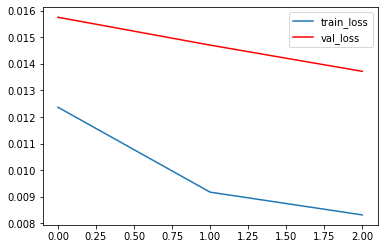

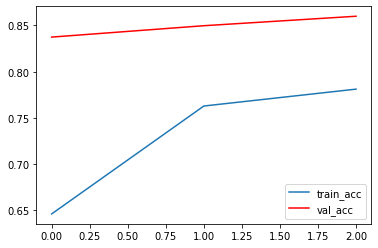

In [ ]:
# plot them out
m.plot()

## Prediction

In [ ]:
best_model.eval()

total_out = []
for text, mask in tqdm(test_data, total=len(test_data)):
    text = text.to(device)
    mask = mask.to(device)

    output = best_model(text, mask)
    pred = output
    pred = torch.argmax(pred, dim=1)
    total_out.append(pred)

total_out = torch.cat(total_out).cpu().numpy().tolist()

with open('pred.csv', 'w') as f:
    f.write('index,sentiment_label\n')
    for i, pred in enumerate(total_out):
        f.write('{},{}\n'.format(i, pred))

100%|██████████| 92/92 [00:11<00:00,  8.06it/s]
